<a href="https://colab.research.google.com/github/JosuBarrado/03MIAR_Algortimos-de-Optimizacion---2025/blob/main/Algoritmos_AG3_Plantilla(no_borrar).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AG3 - Actividad Guiada 3
Nombre: Raul Reyero <br>
Link:   https://colab.research.google.com/drive/17F8C2kwfpMlJnMHxAVEh7twFnAFkMjAL?usp=sharing <br>
Github: https://github.com/JosuBarrado/03MIAR_Algortimos-de-Optimizacion---2025.git
<br>




In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

##Programación Dinámica. Viaje por el rio
* **Definición**: Es posible dividir el problema en subproblemas más pequeños, guardando las soluciones para ser utilizadas más adelante.
* **Características** que permiten identificar problemas aplicables:<br>
  -Es posible almacenar soluciones de los subproblemas para ser utilizados más adelante<br>
  -Debe verificar el principio de optimalidad de Bellman: “en una secuencia optima de decisiones, toda sub-secuencia también es óptima” (*)<br>
  -La necesidad de guardar la información acerca de las soluciones parciales unido a la recursividad provoca la necesidad de preocuparnos por la complejidad espacial (cuantos recursos de espacio usaremos)<br>

###Problema<br>
En un río hay **n** embarcaderos y debemos desplazarnos río abajo desde un embarcadero a otro. Cada embarcadero tiene precios diferentes para ir de un embarcadero a otro situado más abajo. Para ir del embarcadero i al j, puede ocurrir que sea más barato hacer un trasbordo por un embarcadero intermedio k. El problema consiste en determinar la combinación más barata.

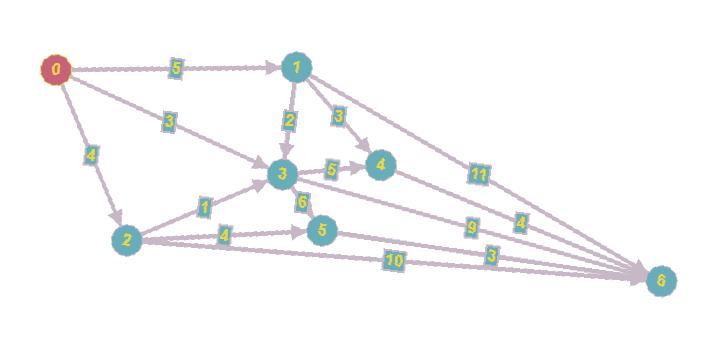

*Consideramos una tabla TARIFAS(i,j) para almacenar todos los precios que nos ofrecen los embarcaderos.<br>
*Si no es posible ir desde i a j daremos un valor alto para garantizar que ese trayecto no se va a elegir en la ruta óptima(modelado habitual para restricciones)

In [2]:
#Viaje por el rio - Programación dinámica
################################################################################

TARIFAS = [
[0,5,4,3,float("inf"),999,999],   #desde nodo 0
[999,0,999,2,3,999,11],  #desde nodo 1
[999,999, 0,1,999,4,10], #desde nodo 2
[999,999,999, 0,5,6,9],
[999,999, 999,999,0,999,4],
[999,999, 999,999,999,0,3],
[999,999,999,999,999,999,0]
]

#999 se puede sustituir por float("inf") del modulo math
TARIFAS

[[0, 5, 4, 3, inf, 999, 999],
 [999, 0, 999, 2, 3, 999, 11],
 [999, 999, 0, 1, 999, 4, 10],
 [999, 999, 999, 0, 5, 6, 9],
 [999, 999, 999, 999, 0, 999, 4],
 [999, 999, 999, 999, 999, 0, 3],
 [999, 999, 999, 999, 999, 999, 0]]

In [3]:
#Calculo de la matriz de PRECIOS y RUTAS
#  PRECIOS - contiene la matriz del mejor precio para ir de un nodo a otro
#  RUTAS   - contiene los nodos intermedios para ir de un nodo a otro
################################################################
def Precios(TARIFAS):
################################################################
  #Total de Nodos
  N = len(TARIFAS[0])

  #Inicialización de la tabla de precios
  PRECIOS = [ [9999]*N for i in [9999]*N]  #n x n
  RUTA = [ [""]*N for i in [""]*N]

  #Se recorren todos los nodos con dos bucles(origen - destino)
  #  para ir construyendo la matriz de PRECIOS
  for i in range(N-1):
    for j in range(i+1, N):
      MIN = TARIFAS[i][j]
      RUTA[i][j] = i

      for k in range(i, j):
        if PRECIOS[i][k] + TARIFAS[k][j] < MIN:
            MIN = min(MIN, PRECIOS[i][k] + TARIFAS[k][j] )
            RUTA[i][j] = k
        PRECIOS[i][j] = MIN

  return PRECIOS,RUTA

In [4]:
PRECIOS,RUTA = Precios(TARIFAS)
#print(PRECIOS[0][6])

print("PRECIOS")
for i in range(len(TARIFAS)):
  print(PRECIOS[i])

print("\nRUTA")
for i in range(len(TARIFAS)):
  print(RUTA[i])

PRECIOS
[9999, 5, 4, 3, 8, 8, 11]
[9999, 9999, 999, 2, 3, 8, 7]
[9999, 9999, 9999, 1, 6, 4, 7]
[9999, 9999, 9999, 9999, 5, 6, 9]
[9999, 9999, 9999, 9999, 9999, 999, 4]
[9999, 9999, 9999, 9999, 9999, 9999, 3]
[9999, 9999, 9999, 9999, 9999, 9999, 9999]

RUTA
['', 0, 0, 0, 1, 2, 5]
['', '', 1, 1, 1, 3, 4]
['', '', '', 2, 3, 2, 5]
['', '', '', '', 3, 3, 3]
['', '', '', '', '', 4, 4]
['', '', '', '', '', '', 5]
['', '', '', '', '', '', '']


In [5]:
#Calculo de la ruta usando la matriz RUTA
def calcular_ruta(RUTA, desde, hasta):
  if desde == RUTA[desde][hasta]:
  #if desde == hasta:
    #print("Ir a :" + str(desde))
    return desde
  else:
    return str(calcular_ruta(RUTA, desde, RUTA[desde][hasta])) +  ',' + str(RUTA[desde][hasta])

print("\nLa ruta pasa por :")
print(calcular_ruta(RUTA, 0,6) )
print("Con valor" , PRECIOS[0][6])



La ruta pasa por :
0,2,5
Con valor 11


##Problema de Asignacion de tarea

In [6]:
#Asignacion de tareas - Ramificación y Poda
################################################################################
#    T A R E A
#   A
#   G
#   E
#   N
#   T
#   E

COSTES=[[11,12,18,40],
        [14,15,13,22],
        [11,17,19,23],
        [17,14,20,28]]


In [7]:
#Calculo del valor de una solucion parcial
def valor(S,COSTES):
  VALOR = 0
  for i in range(len(S)):
    VALOR += COSTES[S[i]][i]
  return VALOR



valor((0, 1, 2, 3  ),COSTES)

73

In [8]:
#Coste inferior para soluciones parciales
#  (1,3,) Se asigna la tarea 1 al agente 0 y la tarea 3 al agente 1

def CI(S,COSTES):
  VALOR = 0
  #Valores establecidos
  for i in range(len(S)):
    VALOR += COSTES[i][S[i]]

  #Estimacion
  for i in range( len(S), len(COSTES)   ):
    VALOR += min( [ COSTES[j][i] for j in range(len(S), len(COSTES))  ])
  return VALOR

def CS(S,COSTES):
  VALOR = 0
  #Valores establecidos
  for i in range(len(S)):
    VALOR += COSTES[i][S[i]]

  #Estimacion
  for i in range( len(S), len(COSTES)   ):
    VALOR += max( [ COSTES[j][i] for j in range(len(S), len(COSTES))  ])
  return VALOR

CI((0,1),COSTES)

68

In [9]:
#Genera tantos hijos como como posibilidades haya para la siguiente elemento de la tupla
#(0,) -> (0,1), (0,2), (0,3)
def crear_hijos(NODO, N):
  HIJOS = []
  for i in range(N ):
    if i not in NODO:
      HIJOS.append({'s':NODO +(i,)    })
  return HIJOS

In [10]:
crear_hijos((0,) , 4)

[{'s': (0, 1)}, {'s': (0, 2)}, {'s': (0, 3)}]

In [11]:
def ramificacion_y_poda(COSTES):
#Construccion iterativa de soluciones(arbol). En cada etapa asignamos un agente(ramas).
#Nodos del grafo  { s:(1,2),CI:3,CS:5  }
  #print(COSTES)
  DIMENSION = len(COSTES)
  MEJOR_SOLUCION=tuple( i for i in range(len(COSTES)) )
  CotaSup = valor(MEJOR_SOLUCION,COSTES)
  #print("Cota Superior:", CotaSup)

  NODOS=[]
  NODOS.append({'s':(), 'ci':CI((),COSTES)    } )

  iteracion = 0

  while( len(NODOS) > 0):
    iteracion +=1

    nodo_prometedor = [ min(NODOS, key=lambda x:x['ci']) ][0]['s']
    #print("Nodo prometedor:", nodo_prometedor)

    #Ramificacion
    #Se generan los hijos
    HIJOS =[ {'s':x['s'], 'ci':CI(x['s'], COSTES)   } for x in crear_hijos(nodo_prometedor, DIMENSION) ]

    #Revisamos la cota superior y nos quedamos con la mejor solucion si llegamos a una solucion final
    NODO_FINAL = [x for x in HIJOS if len(x['s']) == DIMENSION  ]
    if len(NODO_FINAL ) >0:
      #print("\n********Soluciones:",  [x for x in HIJOS if len(x['s']) == DIMENSION  ] )
      if NODO_FINAL[0]['ci'] < CotaSup:
        CotaSup = NODO_FINAL[0]['ci']
        MEJOR_SOLUCION = NODO_FINAL

    #Poda
    HIJOS = [x for x in HIJOS if x['ci'] < CotaSup   ]

    #Añadimos los hijos
    NODOS.extend(HIJOS)

    #Eliminamos el nodo ramificado
    NODOS =  [  x for x in NODOS if x['s'] != nodo_prometedor    ]

  print("La solucion final es:" ,MEJOR_SOLUCION , " en " , iteracion , " iteraciones" , " para dimension: " ,DIMENSION  )



ramificacion_y_poda(COSTES)

La solucion final es: [{'s': (1, 2, 0, 3), 'ci': 64}]  en  10  iteraciones  para dimension:  4


### EXTRA

Añado la parte de crear matrices aleatorias de mayor dimensión y ver a partir de que dimensión se tarda mucho en la ejecución.

In [65]:
#### TABLA DE TIEMPOS DE EJECUCIÓN
import time
import tabulate
import math

tiempo = []
matriz = []
for n in range(5, 10):
  t0 = time.perf_counter()
  matriz1 = np.random.randint(1, 40, size=(n, n))
  ramificacion_y_poda(matriz1)
  t1 = time.perf_counter()
  deltaT = 0 if math.isclose(t1, t0) else (t1 - t0)
  tiempo.append(deltaT)
  matriz.append(f"{n}x{n}")

print(f"\nTabla de tiempo de ejecución:")
cabecera = ["Matriz", "Divide y vencerás (s)"]
tabla = list(zip(matriz, tiempo))
print(tabulate.tabulate(tabla, headers=cabecera, tablefmt="grid"))

La solucion final es: [{'s': (1, 0, 4, 3, 2), 'ci': np.int64(22)}]  en  49  iteraciones  para dimension:  5
La solucion final es: [{'s': (5, 2, 1, 0, 3, 4), 'ci': np.int64(55)}]  en  34  iteraciones  para dimension:  6
La solucion final es: [{'s': (4, 2, 3, 1, 0, 6, 5), 'ci': np.int64(73)}]  en  160  iteraciones  para dimension:  7
La solucion final es: [{'s': (0, 2, 7, 6, 5, 4, 1, 3), 'ci': np.int64(66)}]  en  2568  iteraciones  para dimension:  8
La solucion final es: [{'s': (3, 6, 8, 1, 0, 2, 7, 5, 4), 'ci': np.int64(54)}]  en  5312  iteraciones  para dimension:  9

Tabla de tiempo de ejecución:
+----------+-------------------------+
| Matriz   |   Divide y vencerás (s) |
+==========+=========================+
| 5x5      |              0.00112598 |
+----------+-------------------------+
| 6x6      |              0.00099614 |
+----------+-------------------------+
| 7x7      |              0.00646551 |
+----------+-------------------------+
| 8x8      |              0.4843     |
+---

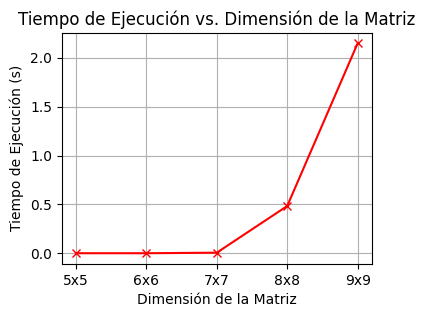

In [71]:
plt.figure(figsize=(4, 3))
plt.plot(matriz, tiempo, marker='x', linestyle='-', color='red')
plt.xlabel('Dimensión de la Matriz')
plt.ylabel('Tiempo de Ejecución (s)')
plt.title('Tiempo de Ejecución vs. Dimensión de la Matriz')
plt.grid(True)
plt.show()

##Descenso del gradiente

A partir de dimensión nueve el cálculo de la tarifa óptima puede verse dificultado devido al crecimiento de la gráfica. Sin embargo, al ser valores aleatorios no siempre tiene que ser este el caso, ya que puede verse drásticamente reducido en caso de podas tempranas. No hay un valor exacto en el que el algoritmo deja de ser viable.

In [12]:
import math                      #Funciones matematicas
import matplotlib.pyplot as plt  #Generacion de gráficos (otra opcion seaborn)
import numpy as np               #Tratamiento matriz N-dimensionales y otras (fundamental!)
#import scipy as sc

import random

Vamos a buscar el minimo de la funcion paraboloide por le metodo del descenso del gradiente : $$f(x) =  x² + y²$$

Obviamente se encuentra en (x,y)=(0,0) pero probaremos como llegamos a él a través del descenso del gradiante.

In [13]:
#Definimos la funcion(f) y el gradiente(df)
#Paraboloide
f  = lambda X:      X[0]**2 + X[1]**2    #Funcion
df = lambda X: [2*X[0] , 2*X[1]]         #Gradiente

df([1,2])

[2, 4]

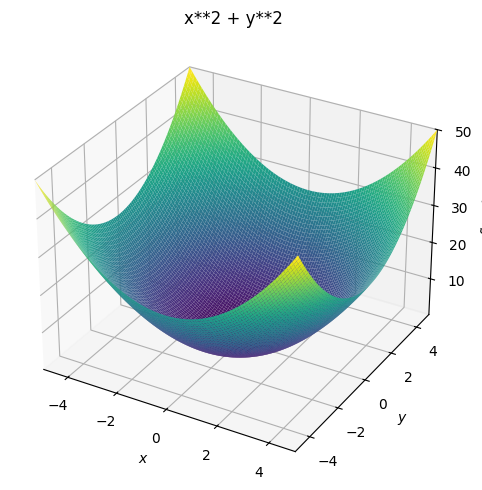

In [14]:
from sympy import symbols
from sympy.plotting import plot
from sympy.plotting import plot3d
x,y = symbols('x y')
plot3d(x**2 + y**2,
       (x,-5,5),(y,-5,5),
       title='x**2 + y**2',
       size=(5,5));

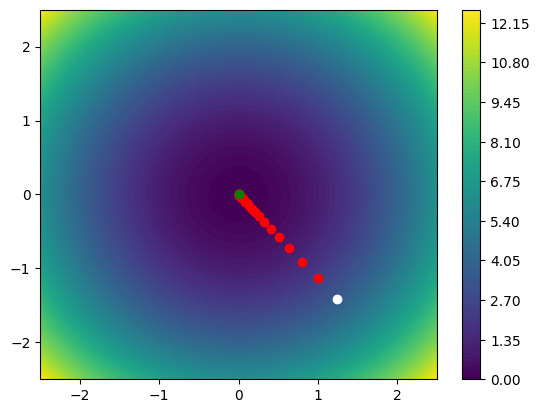

Solucion: [1.7745605052069574e-05, -2.0258853943681685e-05] 7.253276617754641e-10


In [15]:
#Prepara los datos para dibujar mapa de niveles de Z
resolucion = 100
rango=2.5

X=np.linspace(-rango,rango,resolucion)
Y=np.linspace(-rango,rango,resolucion)
Z=np.zeros((resolucion,resolucion))
for ix,x in enumerate(X):
  for iy,y in enumerate(Y):
    Z[iy,ix] = f([x,y])

#Pinta el mapa de niveles de Z
plt.contourf(X,Y,Z,resolucion)
plt.colorbar()

#Generamos un punto aleatorio inicial y pintamos de blanco
P=[random.uniform(-2,2  ),random.uniform(-2,2 ) ]
plt.plot(P[0],P[1],"o",c="white")

#Tasa de aprendizaje. Fija. Sería más efectivo reducirlo a medida que nos acercamos.
TA=.1

#Iteraciones:500
for _ in range(50):
  grad = df(P)
  #print(P,grad)
  P[0],P[1] = P[0] - TA*grad[0] , P[1] - TA*grad[1]
  plt.plot(P[0],P[1],"o",c="red")

#Dibujamos el punto final y pintamos de verde
plt.plot(P[0],P[1],"o",c="green")
plt.show()
print("Solucion:" , P , f(P))


**¿Te atreves a optimizar la función?:**

$$f(x)=sin(1/2 * x^2 - 1/4 * y^2 + 3) * cos(2*x + 1 - e^y)$$
<br>
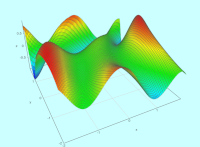


Me atrebo a optimizar esta función. Primero voy a dividir el problema en partes menores para ir solucionandolo y tener éxito. 😄

In [16]:
#Definimos la funcion
f= lambda X: np.sin(1/2 * X[0]**2 - 1/4 * X[1]**2 + 3) *np.cos(2*X[0] + 1 - np.exp(X[1]) )


In [17]:
# Defino una función que devuelve el gradiente en un punto aplicando la aproximación de derivada por
# suma infinitesimal.

def grad_f(punto : list):
    grad = np.array([])
    h = 1e-6
    for i in range(len(punto)):
        punto_h = punto.copy()
        punto_h[i] += h
        grad = np.append(grad, ((f(punto_h) - f(punto)) / h))
    return np.round(grad, 2)

In [23]:
def gradient_descent(x0 : list, ratio : float, tol : float, maxit : int):
    it = 0
    gamma = ratio

    # Empezamos calculando el gradiente en el punto inicial x0
    grad_ant = grad_f(x0)
    x_ant = np.array(x0, dtype=float)

    # Criterio de parada si el gradiente es cercano a cero
    # Antes de empezar a hacer iteraciones
    if abs(np.linalg.norm(grad_ant)) < tol:
        print("Se he empezado por un punto máximo o mínimo relativo")
        pass

    puntos = []
    while it < maxit:
        puntos.append(x_ant)
        # Paso de descenso
        x_n = x_ant - gamma * grad_ant
        grad_n = grad_f(x_n)

        # Criterio de parada
        if abs(np.linalg.norm(grad_n)) < tol:
            print("Converge en iteración:", it)
            return np.round(x_n, 2), puntos, grad_ant


        # Avanzar iteración
        x_ant = x_n
        grad_ant = grad_n
        it += 1
    # la funcion devuelve el punto mínimo, los puntos que ha ido calculando hasta llegar a el y el valor de gradiente en el último punto
    return np.round(x_n, 2), puntos, grad_ant

In [24]:
#Definimos la funcion

# Empezando en el punto [3.7, 2.65], con ratio de aprendizaje 0.01, tolerancia 1e-12 y un máximo de 1e5 iteraciones
# Puedes modificar el punto x_ini y_ini y el cálculo se realiza correctamente y la visualización se modifica
# entorno al punto elegido (aunque puede que se tapen partes según a donde llegue el mínimo)
x_ini = 3.7
y_ini = 2.65
gradiente, puntos, gradiente_anterior = gradient_descent([x_ini, y_ini], 0.001, 1e-12 , 1e5)

Converge en iteración: 553


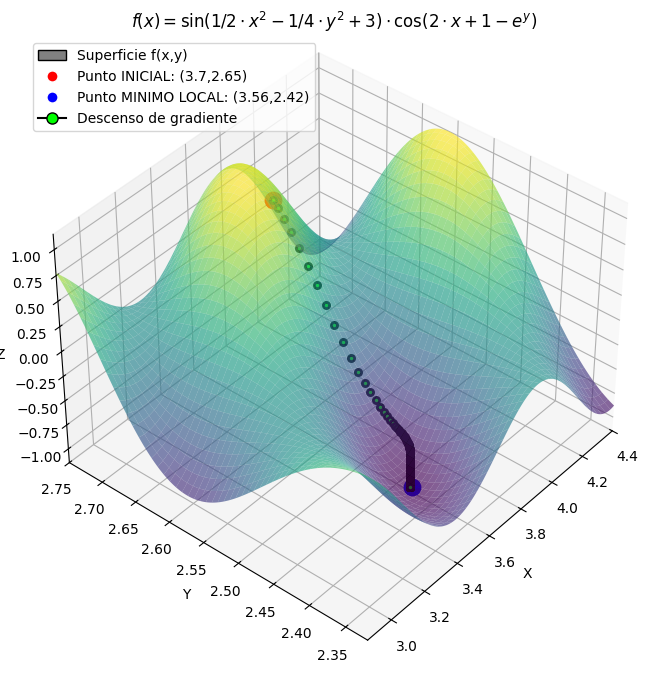

In [25]:
#############################
# VISUALIZACIÓN DESCENSO DE GRADIENTE
#############################

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Grid data sobre la función original
x = np.linspace(min(x_ini, gradiente[0]) - 0.7, max(x_ini, gradiente[0]) + 0.7, 200)
y = np.linspace(min(y_ini, gradiente[1]) - 0.1, max(y_ini, gradiente[1]) + 0.1, 200)
X, Y = np.meshgrid(x, y)
Z = np.sin(1/2 * X**2 - 1/4 * Y**2 + 3) *np.cos(2*X + 1 - np.exp(Y))

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.65,   linewidth=0, antialiased=True)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
surf.set_zsort('min')  # o 'max' según tu caso

# Añado puntos desde donde comenzamos a calcular el descenso de gradiente

Z_satrt = f([x_ini, y_ini])
ax.scatter(x_ini, y_ini, Z_satrt, color='red', s=140)
Z_min = f([gradiente[0], gradiente[1]])
ax.scatter(gradiente[0], gradiente[1], Z_min, color='blue', s=140)


x_puntos = np.array([p[0] for p in puntos])
y_puntos = np.array([p[1] for p in puntos])
z_puntos= f([x_puntos, y_puntos])
# Plotear el camino (puntos verdes)
ax.scatter(x_puntos, y_puntos, z_puntos, color='lime', s=20, edgecolors='black',linewidth=2, depthshade=False, label='Descenso')

ax.set_title(r"$f(x)= \sin(1/2 \cdot x^2 − 1/4 \cdot y^2 + 3) \cdot \cos(2 \cdot x+1−e^y)$")

# Leyenda (proxies)
legend_items = [
    Patch(facecolor='gray', edgecolor='black', label='Superficie f(x,y)'),
    Line2D([0], [0], marker='o', color='w', label=f'Punto INICIAL: ({x_ini},{y_ini})',
           markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label=f'Punto MINIMO LOCAL: ({gradiente[0]},{gradiente[1]})',
           markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='black', label=f'Descenso de gradiente',
           markerfacecolor='lime', markersize=8)
]

ax.view_init(elev=40, azim=220)
ax.legend(handles=legend_items, loc='upper left')

ax.set_xlim(min(x_ini, gradiente[0]) - 0.7, max(x_ini, gradiente[0]) + 0.7)
ax.set_ylim(min(y_ini, gradiente[1]) - 0.1, max(y_ini, gradiente[1]) + 0.1)

plt.show()



##Problema de Autobuses por Fuerza Bruta

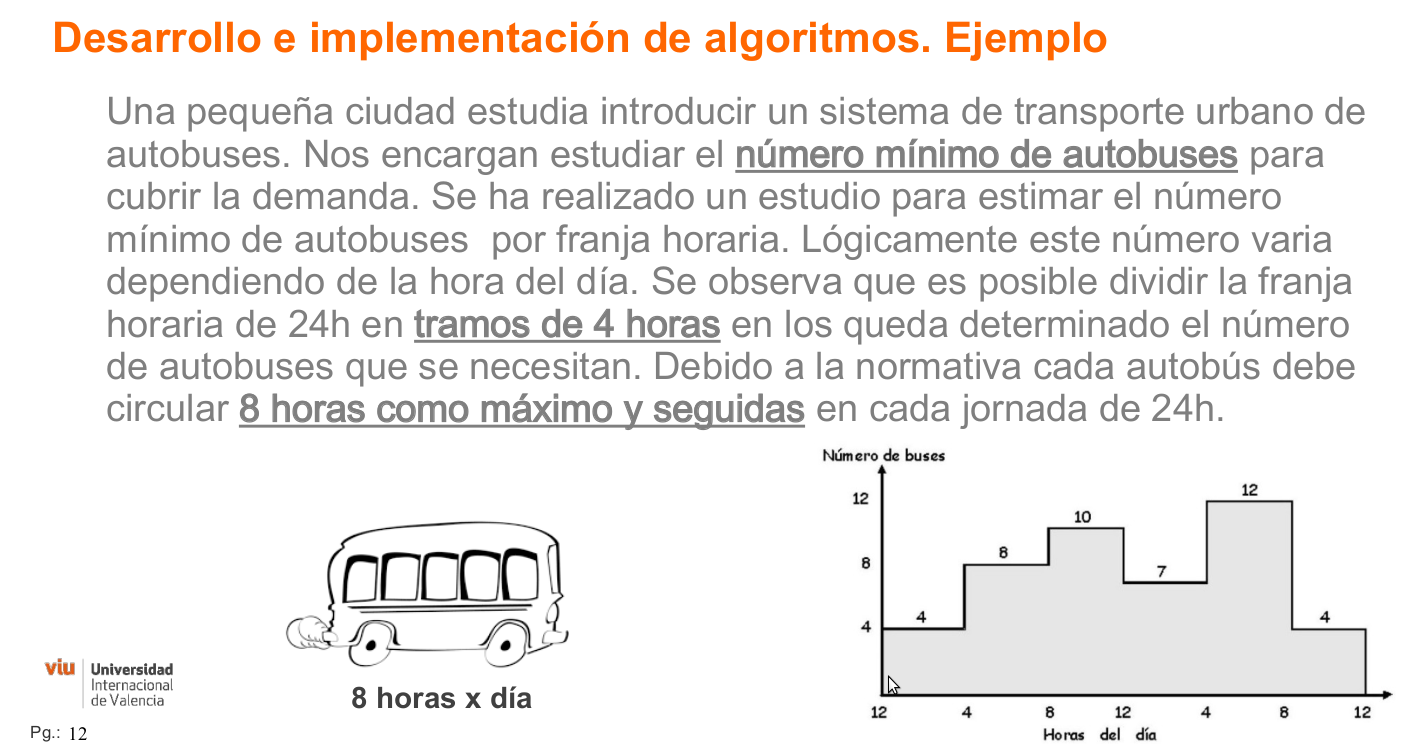

In [21]:
###################################################
# Ximo Sanz Tornero.
###################################################
from itertools import product

# Paso 1: Inicializamos los datos
# Demanda mínima de autobuses por tramo
demanda = [4, 8, 10, 7, 12, 4]  # d[0], d[1], ..., d[5]
tramos = len(demanda)  # Número de tramos (6 en este caso)


#Posible Solucion
x = [4,5,6,7,8,9]

for t in range(tramos):
    # Calculamos el número actual de autobuses que están cubriendo el tramo t
    cobertura_actual = x[t] + x[t - 1]  # Autobuses en t y t-1 (cíclico)

    # Si la cobertura actual es menor que la demanda, añadimos autobuses en t
    if cobertura_actual < demanda[t]:
        # Añadimos los autobuses necesarios en el tramo t
        x[t] += demanda[t] - cobertura_actual

#Función objetivo
f_objetivo = sum(x)


# Se crean funciones tanto para verificar posibles soluciones como para obtener el valor de la función objetivo de la solución
# Función objetivo: suma de todos los x[i]
def funcion_objetivo(solucion):
    return sum(solucion)

# Verificación de restricciones
def verifica_restricciones(solucion):
    for t in range(tramos):
        # Se calcula el número actual de autobuses que están cubriendo el tramo t
        cobertura_actual = solucion[t] + solucion[t - 1]  # Cíclico
        if cobertura_actual < demanda[t]:
            return False
    return True


# Se realiza el algoritmo por fuerza bruta con todas las posibles combinaciones de valores que tenemos en funcion de la variable demanda
# Generación del espacio de soluciones
# Para ver mejor el funcionamiento, ejecutar: for solucion in product(*(range(d + 1) for d in [1,2,3])):   print(solucion)
espacio_soluciones = product(*(range(d + 1) for d in demanda))

# Búsqueda de la mejor solución
mejor_valor_objetivo = float('inf')
mejores_soluciones = []

for solucion in espacio_soluciones:
    if verifica_restricciones(solucion):
        valor_objetivo = funcion_objetivo(solucion)
        if valor_objetivo < mejor_valor_objetivo:
            mejor_valor_objetivo = valor_objetivo
            mejores_soluciones = [solucion]
        elif valor_objetivo == mejor_valor_objetivo:
            mejores_soluciones.append(solucion)  # Agrega soluciones con el mismo valor

# Resultado
print("Mejores soluciones:")
for solucion in mejores_soluciones:
    print(solucion)
print("Valor mínimo de la función objetivo:", mejor_valor_objetivo)



Mejores soluciones:
(0, 8, 2, 5, 7, 4)
(0, 8, 2, 6, 6, 4)
(0, 8, 2, 7, 5, 4)
(1, 7, 3, 4, 8, 3)
(1, 7, 3, 5, 7, 3)
(1, 7, 3, 6, 6, 3)
(1, 7, 3, 7, 5, 3)
(1, 8, 2, 5, 7, 3)
(1, 8, 2, 6, 6, 3)
(1, 8, 2, 7, 5, 3)
(2, 6, 4, 3, 9, 2)
(2, 6, 4, 4, 8, 2)
(2, 6, 4, 5, 7, 2)
(2, 6, 4, 6, 6, 2)
(2, 6, 4, 7, 5, 2)
(2, 7, 3, 4, 8, 2)
(2, 7, 3, 5, 7, 2)
(2, 7, 3, 6, 6, 2)
(2, 7, 3, 7, 5, 2)
(2, 8, 2, 5, 7, 2)
(2, 8, 2, 6, 6, 2)
(2, 8, 2, 7, 5, 2)
(3, 5, 5, 2, 10, 1)
(3, 5, 5, 3, 9, 1)
(3, 5, 5, 4, 8, 1)
(3, 5, 5, 5, 7, 1)
(3, 5, 5, 6, 6, 1)
(3, 5, 5, 7, 5, 1)
(3, 6, 4, 3, 9, 1)
(3, 6, 4, 4, 8, 1)
(3, 6, 4, 5, 7, 1)
(3, 6, 4, 6, 6, 1)
(3, 6, 4, 7, 5, 1)
(3, 7, 3, 4, 8, 1)
(3, 7, 3, 5, 7, 1)
(3, 7, 3, 6, 6, 1)
(3, 7, 3, 7, 5, 1)
(3, 8, 2, 5, 7, 1)
(3, 8, 2, 6, 6, 1)
(3, 8, 2, 7, 5, 1)
(4, 4, 6, 1, 11, 0)
(4, 4, 6, 2, 10, 0)
(4, 4, 6, 3, 9, 0)
(4, 4, 6, 4, 8, 0)
(4, 4, 6, 5, 7, 0)
(4, 4, 6, 6, 6, 0)
(4, 4, 6, 7, 5, 0)
(4, 5, 5, 2, 10, 0)
(4, 5, 5, 3, 9, 0)
(4, 5, 5, 4, 8, 0)
(4, 5, 5, 5, 7, 0)
(4, 5, 

In [22]:
for solucion in product(*(range(d + 1) for d in [1,2,3])):   print(solucion)

(0, 0, 0)
(0, 0, 1)
(0, 0, 2)
(0, 0, 3)
(0, 1, 0)
(0, 1, 1)
(0, 1, 2)
(0, 1, 3)
(0, 2, 0)
(0, 2, 1)
(0, 2, 2)
(0, 2, 3)
(1, 0, 0)
(1, 0, 1)
(1, 0, 2)
(1, 0, 3)
(1, 1, 0)
(1, 1, 1)
(1, 1, 2)
(1, 1, 3)
(1, 2, 0)
(1, 2, 1)
(1, 2, 2)
(1, 2, 3)
